### Importación de Librerías y Configuración de Dispositivo

In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

# Permitir importar módulos desde src/
BASE_DIR = Path("..")
sys.path.append(str(BASE_DIR))

from src.model import Autoencoder

# Fijar semilla para reproducibilidad
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Detección de hardware (GPU o CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"⚡ Entrenando en dispositivo: {device}")

⚡ Entrenando en dispositivo: cpu


### Carga de Datos Procesados y PyTorch DataLoader

In [2]:
PROCESSED_DATA_PATH = BASE_DIR / "data" / "processed"

# Cargar solo el dataset de entrenamiento LÍCITO
X_train_licit = np.load(PROCESSED_DATA_PATH / "X_train_licit.npy")
print(f"Dimensiones de X_train_licit: {X_train_licit.shape}")

# Convertir a Tensors de PyTorch
X_train_tensor = torch.tensor(X_train_licit, dtype=torch.float32)

# Crear Dataset y DataLoader
BATCH_SIZE = 256
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

Dimensiones de X_train_licit: (26432, 165)


### Instanciación del Modelo, Criterio y Optimizador
La función de pérdida evaluada corresponde al Error Cuadrático Medio ($\mathcal{L}_{\text{MSE}}$):$$\mathcal{L}_{\text{MSE}} = \frac{1}{d} \sum_{i=1}^{d} (x_i - \hat{x}_i)^2$$

In [3]:
# Parámetros
INPUT_DIM = X_train_licit.shape[1]  # 165
BOTTLENECK_DIM = 16
LEARNING_RATE = 1e-3
EPOCHS = 50

# Instanciar modelo
model = Autoencoder(input_dim=INPUT_DIM, bottleneck_dim=BOTTLENECK_DIM).to(device)

# Función de pérdida y optimizador con Weight Decay (regularización L2)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)

print(model)

Autoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=165, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): LeakyReLU(negative_slope=0.2)
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=32, out_features=16, bias=True)
    (9): LeakyReLU(negative_slope=0.2)
  )
  (decoder): Sequential(
    (0): Linear(in_features=16, out_features=32, bias=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=Tr

### Bucle de Entrenamiento (Training Loop)

In [4]:
train_losses = []

model.train()
for epoch in range(1, EPOCHS + 1):
    running_loss = 0.0
    for batch in train_loader:
        inputs = batch[0].to(device)
        
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        
        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        
    epoch_loss = running_loss / len(train_loader.dataset)
    train_losses.append(epoch_loss)
    
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch [{epoch:02d}/{EPOCHS}] - Loss (MSE): {epoch_loss:.6f}")

Epoch [01/50] - Loss (MSE): 0.822252
Epoch [05/50] - Loss (MSE): 0.537763
Epoch [10/50] - Loss (MSE): 0.482583
Epoch [15/50] - Loss (MSE): 0.455044
Epoch [20/50] - Loss (MSE): 0.444419
Epoch [25/50] - Loss (MSE): 0.429087
Epoch [30/50] - Loss (MSE): 0.422030
Epoch [35/50] - Loss (MSE): 0.417056
Epoch [40/50] - Loss (MSE): 0.411381
Epoch [45/50] - Loss (MSE): 0.407517
Epoch [50/50] - Loss (MSE): 0.407069


### Visualización de la Curva de Pérdida

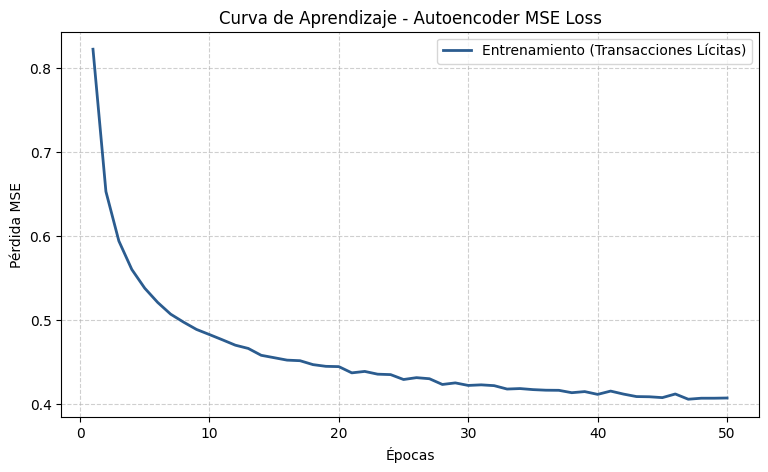

In [5]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, EPOCHS + 1), train_losses, label='Entrenamiento (Transacciones Lícitas)', color='#2b5c8f', lw=2)
plt.title("Curva de Aprendizaje - Autoencoder MSE Loss")
plt.xlabel("Épocas")
plt.ylabel("Pérdida MSE")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

### Guardado del Modelo Entrenado

In [6]:
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "autoencoder_licit.pth"
torch.save(model.state_dict(), model_path)
print(f"💾 Modelo guardado exitosamente en: {model_path}")

💾 Modelo guardado exitosamente en: ..\models\autoencoder_licit.pth
